In [3]:
import gymnasium as gym
import numpy as np
import cv2
import os
import ale_py
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
gym.register_envs(ale_py)

In [4]:
log_dir = "./logs_breakout/"
os.makedirs(log_dir, exist_ok=True)

In [5]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [6]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [7]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [ ]:
def _create_base_gym_env(render_mode, with_modification, modification_type, log_dir=None):
    """
    Função interna para garantir que a ordem dos wrappers seja idêntica
    tanto no treino quanto no vídeo.
    """
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode)
    
    # 1. Garante inicio do jogo
    env = FireResetEnv(env)
    
    # 2. Resize para 84x84 (Colorido)
    # façam sentido na imagem pequena.
    env = gym.wrappers.ResizeObservation(env, (84, 84))
    
    # 3. Aplica a Modificação Visual (Blur ou White Patch)
    if modification_type == 'white_patch':
        env = WhitePatchBreakout(env, apply_patch=with_modification, region=(20, 40, 30, 30))
    elif modification_type == 'blur':
        env = BlurBreakout(env, apply_blur=with_modification, region=(20, 40, 30, 30), ksize=21)
    

    if log_dir:
        env = Monitor(env, log_dir)
        
    return env

In [12]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino mantendo a consistência exata com o ambiente de avaliação.
    Parâmetros renomeados para bater com sua chamada: with_blur, change.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor
        if log_dir:
            env = Monitor(env, log_dir)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [10]:
log_dir_clean = "./logs_clean/"   # Pasta para o treino NORMAL
log_dir_patch = "./logs_patch/"   # Pasta para o treino COM MANCHA

In [ ]:
steps = 1_000_000

In [14]:
print("--- Iniciando Treino SEM Blur ---")
env_normal = make_training_env(with_blur=False, change = 'white_patch', log_dir=log_dir_clean)
model_normal = DQN("CnnPolicy", env_normal, verbose=1, buffer_size=50_000, learning_starts=10_000, train_freq=4) 
model_normal.learn(total_timesteps=steps) # Baixo para teste rápido
model_normal.save("dqn_breakout_normal")
env_normal.close()

--- Iniciando Treino SEM Blur ---
Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 204      |
|    ep_rew_mean      | 1.75     |
|    exploration_rate | 0.961    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1441     |
|    time_elapsed     | 0        |
|    total_timesteps  | 814      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 188      |
|    ep_rew_mean      | 1.5      |
|    exploration_rate | 0.928    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1490     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1507     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 184      |
|    ep_rew_mean      | 1.33     |
|    exploration_rate | 0.895    |
| ti

In [15]:
print("\n--- Iniciando Treino COM Blur ---")
env_blur = make_training_env(with_blur=True, change = 'white_patch', log_dir=log_dir_patch)
model_blur = DQN("CnnPolicy", env_blur, verbose=1, buffer_size=50_000, learning_starts=10_000, train_freq=4)
model_blur.learn(total_timesteps=steps) # Baixo para teste rápido
model_blur.save("dqn_breakout_blur")
env_blur.close()


--- Iniciando Treino COM Blur ---
Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 222      |
|    ep_rew_mean      | 2.5      |
|    exploration_rate | 0.958    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1354     |
|    time_elapsed     | 0        |
|    total_timesteps  | 886      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 217      |
|    ep_rew_mean      | 2.38     |
|    exploration_rate | 0.917    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1399     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1737     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 211      |
|    ep_rew_mean      | 2.17     |
|    exploration_rate | 0.88     |
| t

In [ ]:
def plot_comparison(log_dir_1, name_1, log_dir_2, name_2):
    plt.figure(figsize=(12, 6))
    # Função auxiliar para ler e tratar os dados
    def read_data(folder):
        file_path = os.path.join(folder, "monitor.csv")
        if not os.path.exists(file_path):
            print(f"Aviso: Arquivo não encontrado em {folder}")
            return None, None

        df = pd.read_csv(file_path, skiprows=1)
        x = df['l'].cumsum() # Steps acumulados
        y = df['r']          # Recompensa
        # Suavização (Média móvel de 100 episódios)
        y_smooth = y.rolling(window=100).mean()
        return x, y_smooth


    # Plota o Primeiro (Sem Mancha)
    x1, y1 = read_data(log_dir_1)
    if x1 is not None:
        plt.plot(x1, y1, label=name_1, color='blue', linewidth=2)

    # Plota o Segundo (Com Mancha)
    x2, y2 = read_data(log_dir_2)
    if x2 is not None:
        plt.plot(x2, y2, label=name_2, color='red', linewidth=2, linestyle='--')

    plt.xlabel('Timesteps (Passos)')
    plt.ylabel('Recompensa Média (Média Móvel 100 ep)')
    plt.title('Comparação de Performance: Normal vs Oclusão')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

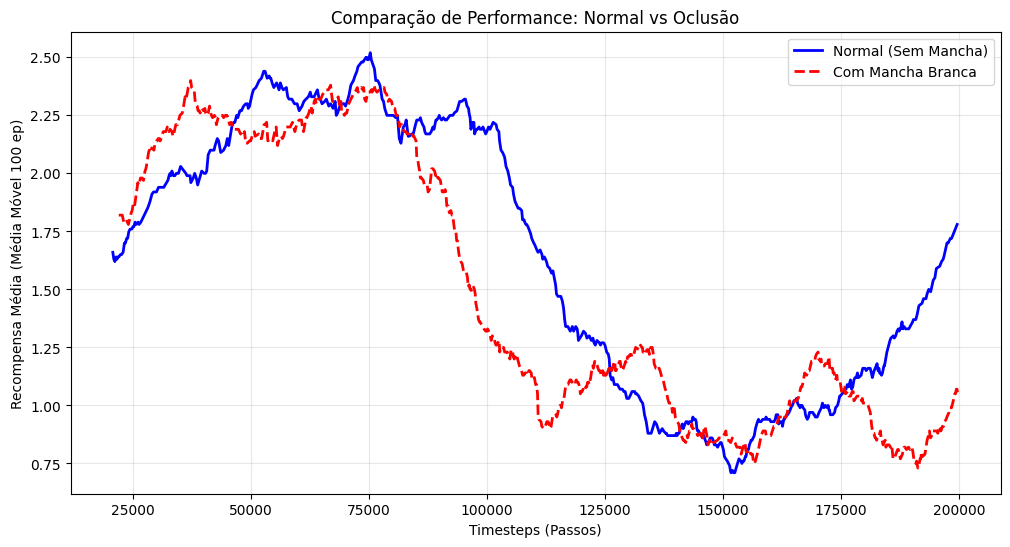

In [9]:
plot_comparison("./logs_clean/", "Normal (Sem Mancha)", "./logs_patch/", "Com Mancha Branca")

In [5]:
def plot_advanced_analysis(log_dir_1, name_1, log_dir_2, name_2):
    
    def read_data(folder):
        file_path = os.path.join(folder, "monitor.csv")
        if not os.path.exists(file_path):
            print(f"Arquivo não encontrado: {folder}")
            return None
        # Pula as duas primeiras linhas (header do SB3)
        df = pd.read_csv(file_path, skiprows=1)
        return df

    df1 = read_data(log_dir_1)
    df2 = read_data(log_dir_2)

    if df1 is None or df2 is None:
        return

    # Cria uma figura com 3 subgráficos (gridspec para layout bonito)
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)
    
    # --- GRÁFICO 1: RECOMPENSA (Média Móvel) ---
    ax1 = fig.add_subplot(gs[0, :]) # Ocupa a linha inteira superior
    
    window = 100
    
    if not df1.empty:
        # Eixo X: Timesteps (l.cumsum), Eixo Y: Recompensa (r)
        x1 = df1['l'].cumsum()
        y1 = df1['r'].rolling(window=window).mean()
        ax1.plot(x1, y1, label=f"{name_1}", color='blue')
        # Sombra de desvio padrão (opcional, para ver estabilidade)
        std1 = df1['r'].rolling(window=window).std()
        ax1.fill_between(x1, y1-std1, y1+std1, color='blue', alpha=0.1)

    if not df2.empty:
        x2 = df2['l'].cumsum()
        y2 = df2['r'].rolling(window=window).mean()
        ax2_line = ax1.plot(x2, y2, label=f"{name_2}", color='red', linestyle='--')
        std2 = df2['r'].rolling(window=window).std()
        ax1.fill_between(x2, y2-std2, y2+std2, color='red', alpha=0.1)

    ax1.set_title("1. Curva de Aprendizado (Recompensa Média)")
    ax1.set_ylabel("Pontos no Breakout")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- GRÁFICO 2: DURAÇÃO DO EPISÓDIO (Sobrevivência) ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    if not df1.empty:
        # Coluna 'l' é o length (frames que durou o jogo)
        y1_len = df1['l'].rolling(window=window).mean()
        ax2.plot(x1, y1_len, color='blue')

    if not df2.empty:
        y2_len = df2['l'].rolling(window=window).mean()
        ax2.plot(x2, y2_len, color='red', linestyle='--')
        
    ax2.set_title("2. Sobrevivência (Duração do Jogo)")
    ax2.set_ylabel("Frames por Episódio")
    ax2.set_xlabel("Total Timesteps")
    ax2.grid(True, alpha=0.3)
    
    # Anotação importante
    ax2.text(0.05, 0.9, 'Cuidado: Se subir aqui mas não\nna recompensa = Agente Travado', 
             transform=ax2.transAxes, fontsize=9, bbox=dict(facecolor='yellow', alpha=0.5))

    # --- GRÁFICO 3: VELOCIDADE DE TREINO (FPS Real) ---
    ax3 = fig.add_subplot(gs[1, 1])
    
    if not df1.empty:
        # Coluna 't' é tempo decorrido em segundos
        # FPS aproximado = total_steps / total_time
        fps1 = x1.iloc[-1] / df1['t'].iloc[-1]
        ax3.bar(name_1, fps1, color='blue', alpha=0.6)
        ax3.text(name_1, fps1, f"{int(fps1)} FPS", ha='center', va='bottom')

    if not df2.empty:
        fps2 = x2.iloc[-1] / df2['t'].iloc[-1]
        ax3.bar(name_2, fps2, color='red', alpha=0.6)
        ax3.text(name_2, fps2, f"{int(fps2)} FPS", ha='center', va='bottom')

    ax3.set_title("3. Velocidade de Treinamento (FPS)")
    ax3.set_ylabel("Frames por Segundo")

    plt.tight_layout()
    plt.show()

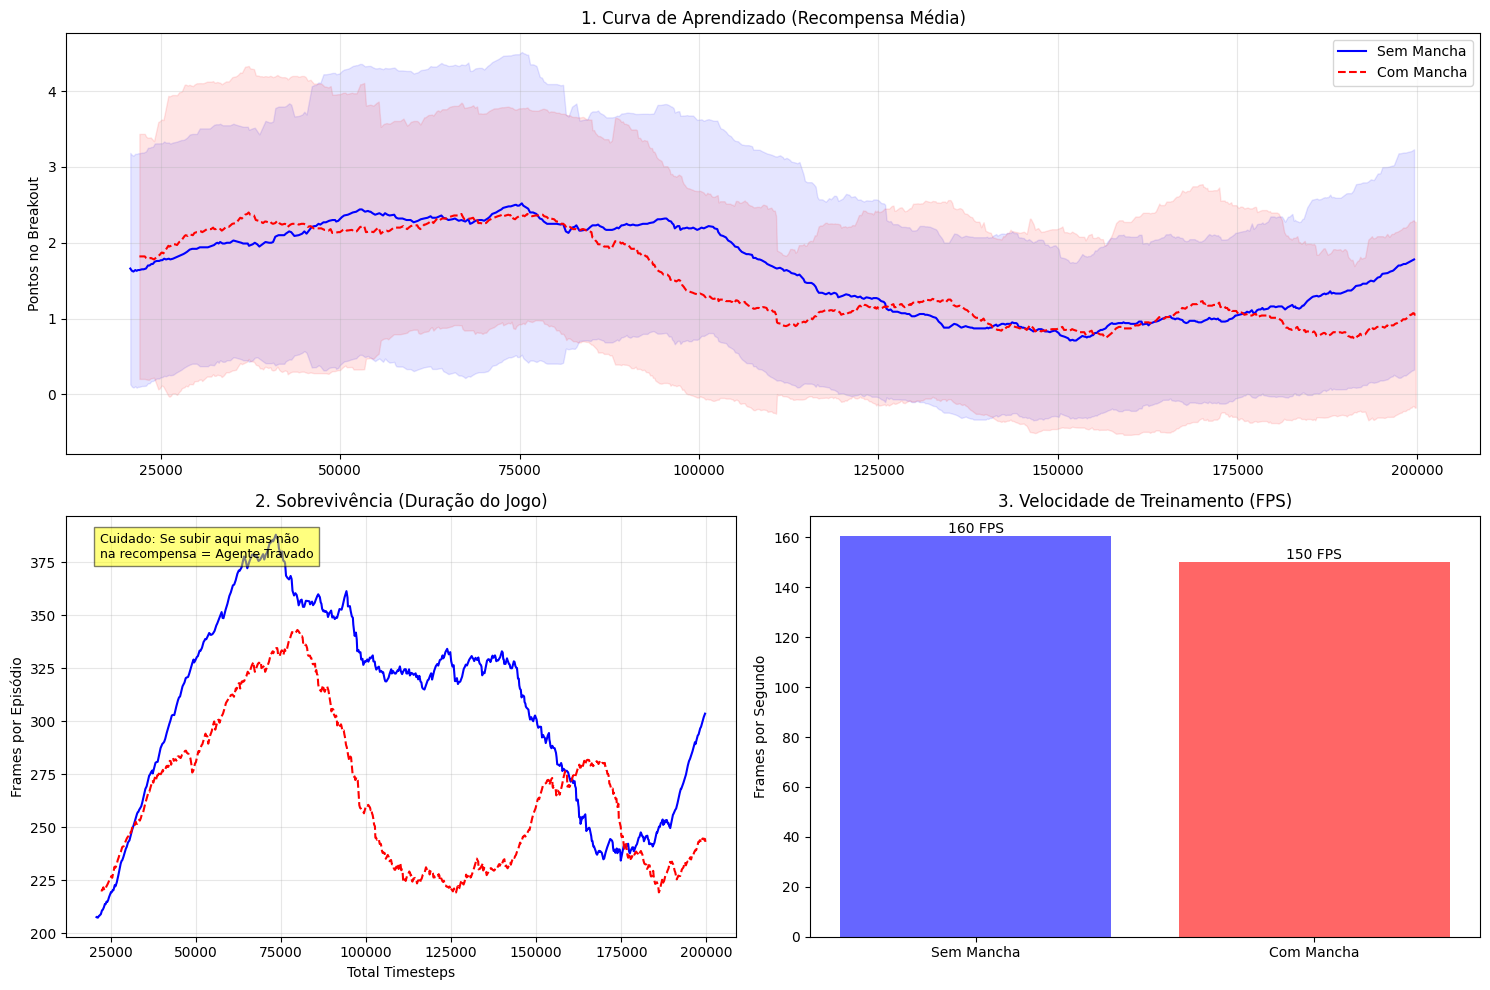

In [7]:
# Chama a função comparando as pastas que criamos antes
plot_advanced_analysis("./logs_clean/", "Sem Mancha", "./logs_patch/", "Com Mancha")

In [ ]:
def record_video(model, name_prefix, with_blur, change='white_patch', n_episodes=1, max_steps=3000):
    video_folder = "./videos/"
    os.makedirs(video_folder, exist_ok=True)
    
    print(f"--- Gravando {name_prefix} (Max {max_steps} steps) ---")

    # 1. Configura ambiente
    def _create_video_env():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env) # Start inicial
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # Grava colorido e com a mancha
        env = gym.wrappers.RecordVideo(
            env, 
            video_folder=video_folder, 
            name_prefix=name_prefix,
            episode_trigger=lambda x: True,
            disable_logger=True
        )
        
        env = GrayscaleWrapper(env)
        return env

    env = DummyVecEnv([_create_video_env])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    obs = env.reset()
    episodes_count = 0
    current_steps = 0
    
    # Rastrear vidas para saber quando apertar FIRE
    last_lives = 5 
    
    try:
        while episodes_count < n_episodes:
            action, _ = model.predict(obs, deterministic=True)
            
            # --- SEGURANÇA 1: Force Fire se perdeu vida ---
            # Precisamos acessar o info interno, mas no step anterior.
            # Como é difícil acessar info antes do step, vamos usar uma heurística:
            # Se o agente ficar 20 steps sem recompensa, tenta FIRE (ação 1)
            
            obs, rewards, done, infos = env.step(action)
            current_steps += 1
            
            # Checa vidas no info
            for info in infos:
                lives = info.get("lives", 0)
                if lives < last_lives:
                    # Perdeu vida! Forçar FIRE no próximo passo seria ideal, 
                    last_lives = lives
                    # Dica: Se o agente for muito ruim, ele pode precisar de ajuda manual aqui
            
            # --- SEGURANÇA 2: Limite de Passos (Corta vídeo infinito) ---
            if current_steps > max_steps:
                print(f"ALERTA: Episódio excedeu {max_steps} passos. Forçando parada.")
                done = [True] # Força reinício
            
            # Verifica fim de episódio real
            for i, d in enumerate(done):
                if d:
                    episodes_count += 1
                    current_steps = 0
                    last_lives = 5
                    # Recupera score se disponível
                    score = infos[i].get('episode', {}).get('r', 0)
                    print(f"Episódio {episodes_count} finalizado | Score: {score}")
                    obs = env.reset() # Garante reset limpo
                    
    except KeyboardInterrupt:
        print("Interrompido.")
    finally:
        env.close()
        print(f"Vídeos salvos em {video_folder}")

In [ ]:
record_video(model_blur, "teste_com_blur", with_blur=True, change = 'white_patch')

--- Iniciando Gravação: teste_com_blur (white_patch=True) ---


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\user\Documents\mestrado\BlurRL\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
record_video(model_normal, "teste_sem_blur", with_blur=False, change = 'white_patch', n_episodes=2)

--- Gravando 2 Episódios ---
Episódio 1 | Score: 0.0
Episódio 2 | Score: 2.0
MoviePy - Building video c:\Users\user\Documents\mestrado\BlurRL\videos\teste_sem_blur-step-0-to-step-100000.mp4.
MoviePy - Writing video c:\Users\user\Documents\mestrado\BlurRL\videos\teste_sem_blur-step-0-to-step-100000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\user\Documents\mestrado\BlurRL\videos\teste_sem_blur-step-0-to-step-100000.mp4
Vídeo salvo em ./videos/
